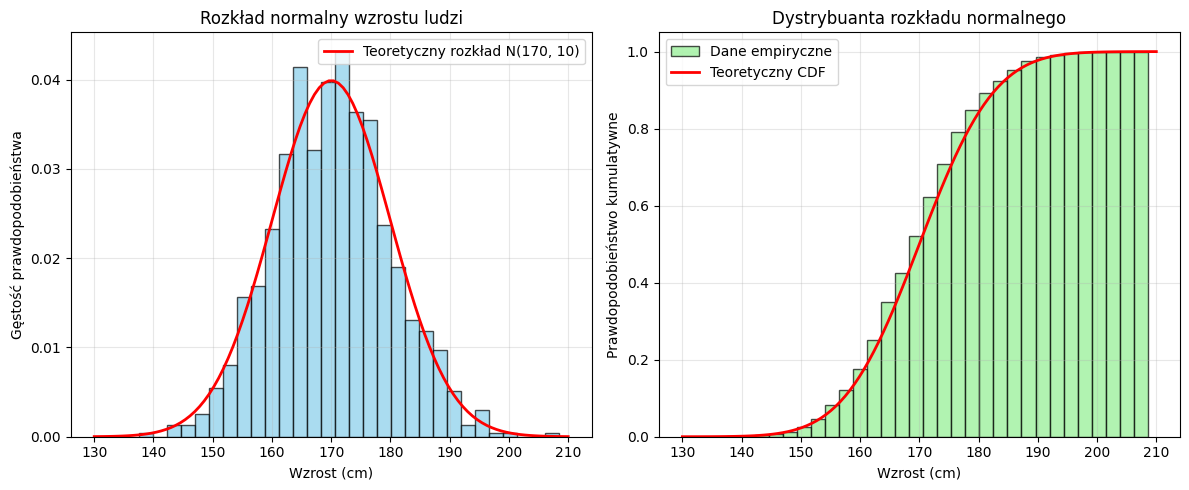

Prawdopodobieństwo wzrostu < 160cm: 0.1587 (15.87%)
Prawdopodobieństwo 160 < wzrost < 180: 0.6827 (68.27%)

Reguła trzech sigm:
 68.27% danych w [μ-σ, μ+σ]: 0.6827
 95.45% danych w [μ-2σ, μ+2σ]: 0.9545
 99.73% danych w [μ-3σ, μ+3σ]: 0.9973


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Parametry rozkładu normalnego
mean = 170 # średnia (μ) - wzrost w cm
std = 10 # odchylenie standardowe (σ)

# Generowanie danych z rozkładu normalnego
np.random.seed(42)
heights = np.random.normal(loc=mean, scale=std, size=1000)

# Wizualizacja rozkładu
plt.figure(figsize=(12, 5))

# Histogram z danymi
plt.subplot(1, 2, 1)
plt.hist(heights, bins=30, density=True, alpha=0.7, color='skyblue', edgecolor='black')

# Teoretyczna krzywa rozkładu normalnego
x = np.linspace(mean - 4*std, mean + 4*std, 100)
pdf = stats.norm.pdf(x, loc=mean, scale=std)
plt.plot(x, pdf, 'r-', linewidth=2, label='Teoretyczny rozkład N(170, 10)')
plt.xlabel('Wzrost (cm)')
plt.ylabel('Gęstość prawdopodobieństwa')
plt.title('Rozkład normalny wzrostu ludzi')
plt.legend()
plt.grid(True, alpha=0.3)

# Dystrybuanta (CDF - Cumulative Distribution Function)
plt.subplot(1, 2, 2)
plt.hist(heights, bins=30, density=True, cumulative=True, alpha=0.7,
color='lightgreen', edgecolor='black', label='Dane empiryczne')

# Teoretyczna dystrybuanta
cdf = stats.norm.cdf(x, loc=mean, scale=std)
plt.plot(x, cdf, 'r-', linewidth=2, label='Teoretyczny CDF')
plt.xlabel('Wzrost (cm)')
plt.ylabel('Prawdopodobieństwo kumulatywne')
plt.title('Dystrybuanta rozkładu normalnego')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Obliczanie prawdopodobieństw
# P(X < 160) - prawdopodobieństwo, że wzrost < 160cm
prob_below_160 = stats.norm.cdf(160, loc=mean, scale=std)
print(f"Prawdopodobieństwo wzrostu < 160cm: {prob_below_160:.4f} ({prob_below_160*100:.2f}%)")

# P(160 < X < 180) - prawdopodobieństwo wzrostu między 160 a 180cm
prob_between = stats.norm.cdf(180, loc=mean, scale=std) - stats.norm.cdf(160, loc=mean, scale=std)
print(f"Prawdopodobieństwo 160 < wzrost < 180: {prob_between:.4f} ({prob_between*100:.2f}%)")

# Reguła trzech sigm: ~68% danych w przedziale [μ-σ, μ+σ]
prob_1sigma = stats.norm.cdf(mean + std, loc=mean, scale=std) - stats.norm.cdf(mean - std, loc=mean, scale=std)
prob_2sigma = stats.norm.cdf(mean + 2*std, loc=mean, scale=std) - stats.norm.cdf(mean - 2*std, loc=mean, scale=std)
prob_3sigma = stats.norm.cdf(mean + 3*std, loc=mean, scale=std) - stats.norm.cdf(mean - 3*std, loc=mean, scale=std)

print(f"\nReguła trzech sigm:")
print(f" 68.27% danych w [μ-σ, μ+σ]: {prob_1sigma:.4f}")
print(f" 95.45% danych w [μ-2σ, μ+2σ]: {prob_2sigma:.4f}")
print(f" 99.73% danych w [μ-3σ, μ+3σ]: {prob_3sigma:.4f}")

Dataset California Housing:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

Shape: (20640, 9)

Kolumny: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']

Podstawowe statystyki:
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671   

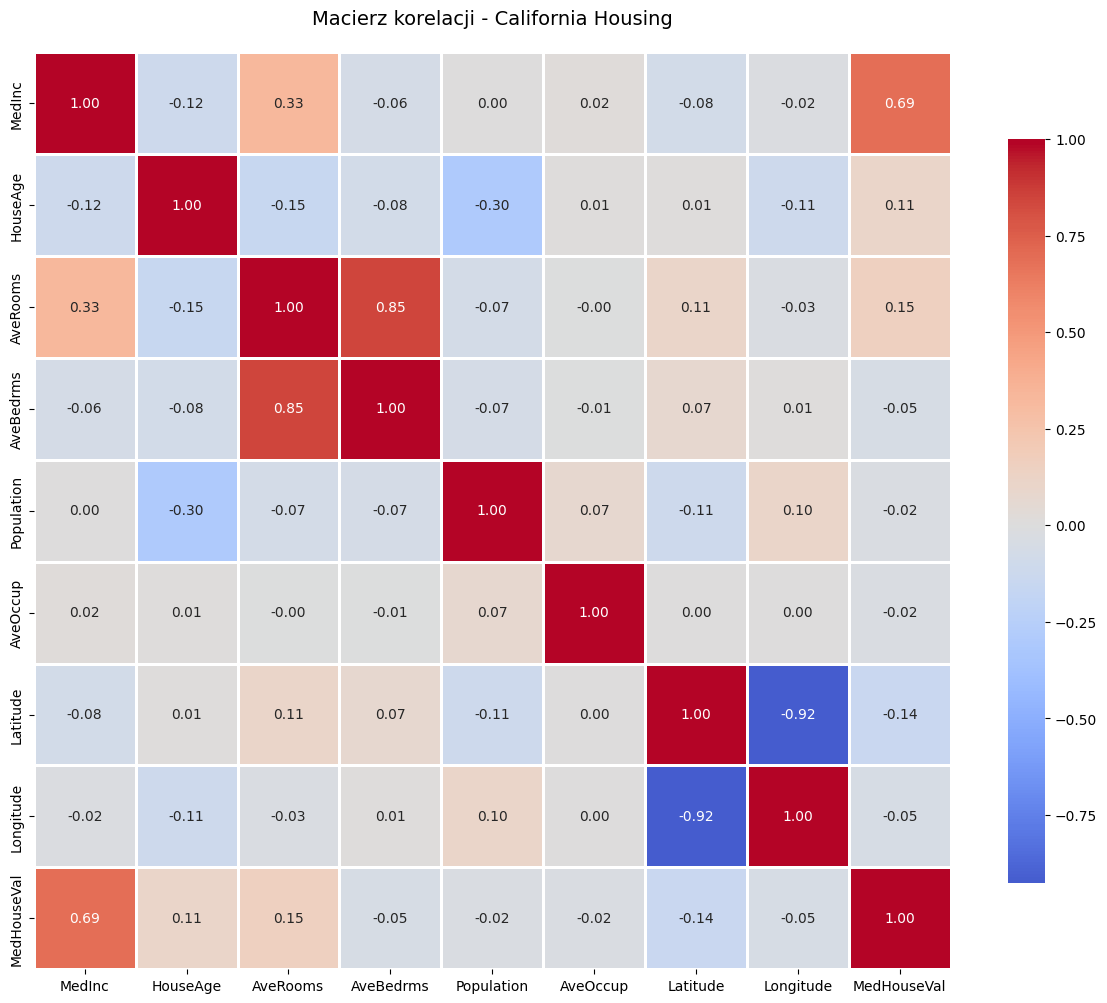


Korelacja Pearsona między MedInc a MedHouseVal:
 Współczynnik korelacji r = 0.6881
 p-value = 0.000000
 → Korelacja JEST istotna statystycznie (p < 0.001)


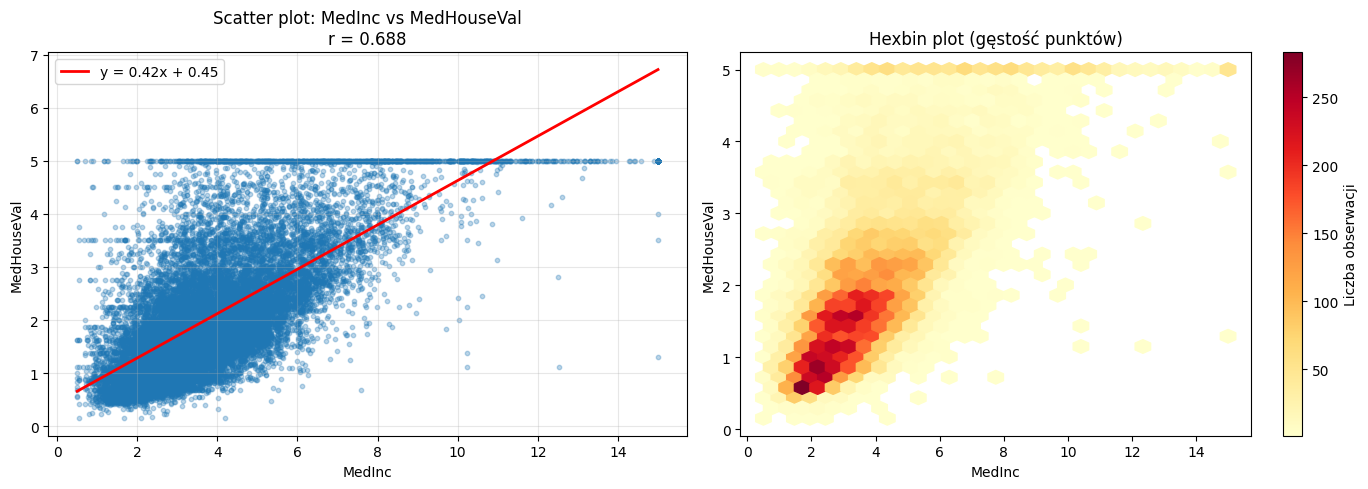

In [3]:
#Korelacje

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
# Wczytanie datasetu California Housing
from sklearn.datasets import fetch_california_housing
housing_data = fetch_california_housing(as_frame=True)
housing = housing_data.frame
print("Dataset California Housing:")
print(housing.head())
print(f"\nShape: {housing.shape}")
print(f"\nKolumny: {list(housing.columns)}")
# Podstawowe statystyki
print("\nPodstawowe statystyki:")
print(housing.describe())
# Obliczenie macierzy korelacji
corr_matrix = housing.corr()
print("\nMacierz korelacji z ceną (MedHouseVal):")
print(corr_matrix['MedHouseVal'].sort_values(ascending=False))
# Wizualizacja macierzy korelacji - heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Macierz korelacji - California Housing', fontsize=14, pad=20)
plt.tight_layout()
plt.show()
# Szczegółowa analiza korelacji - przykład MedInc vs MedHouseVal
feature_x = 'MedInc'
feature_y = 'MedHouseVal'

# Obliczenie współczynnika korelacji Pearsona
corr_coef, p_value = pearsonr(housing[feature_x], housing[feature_y])
print(f"\nKorelacja Pearsona między {feature_x} a {feature_y}:")
print(f" Współczynnik korelacji r = {corr_coef:.4f}")
print(f" p-value = {p_value:.6f}")
if p_value < 0.001:
    print(f" → Korelacja JEST istotna statystycznie (p < 0.001)")
else:
    print(f" → Korelacja NIE JEST istotna (p >= 0.001)")

# Interpretacja siły korelacji
if abs(corr_coef) > 0.7:
    strength = "silna"
elif abs(corr_coef) > 0.4:
    strength = "umiarkowana"
elif abs(corr_coef) > 0.2:
    strength = "słaba"
else:
    strength = "bardzo słaba"
    direction = "dodatnia" if corr_coef > 0 else "ujemna"
    print(f" Interpretacja: Korelacja {strength} {direction}")

# Scatter plot z linią regresji
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Wykres punktowy
ax1 = axes[0]
ax1.scatter(housing[feature_x], housing[feature_y], alpha=0.3, s=10)

# Dodanie linii regresji
z = np.polyfit(housing[feature_x], housing[feature_y], 1)
p = np.poly1d(z)
x_line = np.linspace(housing[feature_x].min(), housing[feature_x].max(), 100)
ax1.plot(x_line, p(x_line), "r-", linewidth=2, label=f'y = {z[0]:.2f}x + {z[1]:.2f}')
ax1.set_xlabel(feature_x)
ax1.set_ylabel(feature_y)
ax1.set_title(f'Scatter plot: {feature_x} vs {feature_y}\nr = {corr_coef:.3f}')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Hexbin plot (dla dużych datasetów)
ax2 = axes[1]
hexbin = ax2.hexbin(housing[feature_x], housing[feature_y], gridsize=30, cmap='YlOrRd', mincnt=1)
ax2.set_xlabel(feature_x)
ax2.set_ylabel(feature_y)
ax2.set_title(f'Hexbin plot (gęstość punktów)')
plt.colorbar(hexbin, ax=ax2, label='Liczba obserwacji')
plt.tight_layout()
plt.show()